# ES Overnight Trend

## Contents

- [Configuration](#configuration)
- [Market Data](#market-data)
  - [ES-SPX Spread](#es-spx-spread)
- [Trend Indicators](#trend-indicators)
- [Chart](#chart)
- [Slide](#slide)
- [Video Script](#video-script)
- [Video](#video)

## ES-SPX Spread
[top](#contents)

To accurately compute the **premium or discount between ES and SPX**, we must **time-align the prices**, because:

- **SPX** is a **cash index** traded during RTH (09:30–16:00 US ET).
- **ES** futures trade nearly 24 hours (with a break from 17:00–18:00 ET), so the latest quote may reflect **after-hours sentiment**.

## ✅ Best Practices to Calculate Accurate ES–SPX Spread

1. Align by timestamp using intraday data
   - Download intraday data (e.g., 1-minute or 5-minute bars) for both ES and SPX.
   - Merge by timestamp and compare **only during SPX trading hours** (09:30–16:00 US ET).
   - Calculate spread at each point, then optionally average.

2. Use 5-minute closing price near 16:00
   - This approximates the **official SPX close** and aligns with ES active trading.

3. Use VWAP or average price over matching session
   - Compute volume-weighted average price (VWAP) or simple average for both ES and SPX over the RTH session, then compare.

In [1]:
import yfinance as yf
import pandas as pd


def compute_es_spx_spread():
    tickers = ["ES=F", "^GSPC"]
    df = yf.download(tickers, period="5d", interval="1m", auto_adjust=False)
    df = df.drop(["High", "Low", "Open", "Adj Close", "Volume"], axis=1)
    df = df.dropna()

    columns = df.columns.get_level_values(1).tolist()

    if isinstance(df.columns, pd.MultiIndex):
        column_names = ["Datetime"] + columns
        df = df.reset_index()
        df.columns = column_names
        df = df.set_index("Datetime")

    df.rename(columns={"ES=F": "ES", "^GSPC": "SPX"}, inplace=True)

    # Convert to desired timezone, e.g., US/Eastern
    df.index = df.index.tz_convert("US/Eastern")

    # Keep only SPX trading hours (RTH)
    df = df.between_time("09:30", "16:05")

    # Calculate spread
    df["Premium"] = df["ES"] - df["SPX"]
    df["% Premium"] = (df["Premium"] / df["SPX"]) * 100

    # Optional: Average premium
    avg_premium = df["Premium"].mean()
    avg_pct = df["% Premium"].mean()

    print(f"\nAverage Premium: {avg_premium:.2f} ({avg_pct:.2f}%)")

    return avg_premium, avg_pct

In [2]:
sprd_premium, sprd_pct = compute_es_spx_spread()

[*********************100%***********************]  2 of 2 completed


Average Premium: 19.70 (0.31%)


## Configuration
[top](#contents)

In [3]:
from pydantic import BaseModel
from typing import Optional


class EsTechnical(BaseModel):
    name: str
    interval: str
    rth_close_datetime: str
    rth_close_price: str
    premium_to_spot: str
    premium_interpretation: str
    overnight_last_date: Optional[str] = None
    overnight_last_time: Optional[str] = None
    overnight_high: Optional[str] = None
    overnight_low: Optional[str] = None

## Market Data
[top](#contents)

In [6]:
import yfinance as yf
import pandas as pd


def get_es_data() -> pd.DataFrame:
    # Define ticker and interval
    ticker = "ES=F"
    interval = "15m"  # 15-minute bars
    period = "5d"  # max is 60d for intraday data

    # Download data
    df = yf.download(ticker, period=period, interval=interval, auto_adjust=True)

    # Flatten multi-index columns
    if isinstance(df.columns, pd.MultiIndex):
        column_names = ["Datetime"] + df.columns.get_level_values(0).tolist()
        df = df.reset_index()
        df.columns = column_names
        df = df.set_index("Datetime")

    # Convert to desired timezone, e.g., US/Eastern
    df.index = df.index.tz_convert("US/Eastern")

    # Save to CSV
    df.to_csv("../output/data/es/prices.csv")
    print("Data saved to ../output/data/es/prices.csv")

    return df

In [7]:
# Show the last few rows
df = get_es_data()
df.tail()

[*********************100%***********************]  1 of 1 completed

Data saved to ../output/data/es/prices.csv


,Close,High,Low,Open,Volume
Datetime,,,,,
2025-08-20 22:00:00-04:00,6417.50,6417.50,6413.75,6416.00,2184
2025-08-20 22:15:00-04:00,6417.75,6419.00,6415.50,6417.50,1708
2025-08-20 22:30:00-04:00,6417.75,6418.75,6416.25,6417.75,777
2025-08-20 22:45:00-04:00,6417.25,6418.25,6416.00,6417.50,658
2025-08-20 23:00:00-04:00,6417.25,6417.50,6417.25,6417.50,0


## Trend Indicators
[top](#contents)

In [8]:
import pandas as pd
from datetime import datetime, time


def get_last_close_datetime(df):
    """
    Core function:
      last_date = df.index[-1].date()
      closing_time = f"{last_date} 16:00:00"
      index = df.index.get_loc(closing_time)
    """
    # Get all unique RTH trading dates, sorted
    filtered_df = df.between_time("09:30", "16:00")
    unique_dates = pd.Series(filtered_df.index.date).unique()

    # Default: use last trading day
    if len(unique_dates) < 1:
        raise ValueError("No trading days in data.")
        return None

    timezone = "US/Eastern"
    # Get current time in the same timezone as the data
    now = (
        pd.Timestamp.now(tz=df.index.tz)
        if df.index.tz
        else pd.Timestamp.now(tz=timezone)
    )
    date_now = now.date()

    # Define trading close time (e.g., 16:00)
    trading_close = time(16, 0)

    if date_now.weekday() in [0, 1, 2, 3, 4]:
        last_date = unique_dates[-1]
    else:
        last_date = unique_dates[-2]

    closing_time = f"{last_date} 16:00:00"

    # Try to get the row at 16:00, else get the last available trade
    if not closing_time in df.index:
        target_rows = df[df.index.date == last_date]
        target_row = target_rows.index[-1]  # Timestamp of last available trade
        closing_time = target_row.strftime("%Y-%m-%d %H:%M:%S")

    return closing_time

In [9]:
def get_last_close_row(df):
    closing_datetime = get_last_close_datetime(df)
    index = df.index.get_loc(closing_datetime)
    trading_close_row = df.loc[closing_datetime]
    return index, trading_close_row

In [10]:
debug = False
if debug:
    # Index from function
    index, row = get_last_close_row(df)
    print(index)
    print(row)

    # Validate row index manually --> change the string date.
    idx = df.index.get_loc("2025-07-07 16:00:00")
    print(idx)

In [11]:
import numpy as np


def create_last_close_line(df):
    # index = df.index.get_loc("2025-06-30 16:00:00")
    index, last_row = get_last_close_row(df)
    closing_price = df.iloc[index]["Close"]
    line = pd.Series([np.nan] * len(df), index=df.index)
    right_index = len(df) - 1  # Extend to the end of the DataFrame
    line.iloc[index : right_index + 1] = closing_price

    add_plot = mpf.make_addplot(line, color="red", linestyle="--")

    return add_plot

In [12]:
def overnight_high_low(df):

    # Filter for rows after last trading close
    closing_datetime = get_last_close_datetime(df)
    filtered_df = df[df.index > closing_datetime]

    # Find the highest point in the specified column
    if not filtered_df.empty:
        highest_point = filtered_df["High"].max()
        lowest_point = filtered_df["Low"].min()
        return highest_point, lowest_point
    else:
        return None, None  # Return None if no data is available in the filtered range

## Chart
[top](#contents)

In [13]:
from datetime import time
import numpy as np


def create_session_background_(df):
    """
    Create a background fill to distingush regular/non-regular trading hour.
    """
    # Define regular trading hours
    rth_start = time(9, 30)
    rth_end = time(16, 0)

    # Get price range for background
    price_min = df["Low"].min()
    price_max = df["High"].max()
    price_range = price_max - price_min

    # Create background levels
    background_high = price_max + price_range * 0.1
    background_low = price_min - price_range * 0.1

    # Create session mask
    session_mask = (df.index.time >= rth_start) & (df.index.time <= rth_end)

    # Create fill data
    fill_high = pd.Series(background_high, index=df.index)
    fill_low = pd.Series(background_low, index=df.index)

    # Create RTH fill (light blue)
    rth_fill_high = fill_high.where(session_mask, np.nan)
    rth_fill_low = fill_low.where(session_mask, np.nan)

    # Create overnight fill (light gray)
    overnight_fill_high = fill_high.where(~session_mask, np.nan)
    overnight_fill_low = fill_low.where(~session_mask, np.nan)

    return rth_fill_high, rth_fill_low, overnight_fill_high, overnight_fill_low

In [25]:
import pandas as pd
import numpy as np
from datetime import time
import pytz

def create_session_background(df, timezone='US/Eastern'):
    """
    Create background fills to distinguish different trading sessions:
    1. US Regular Trading Hours (RTH): 9:30 AM - 4:00 PM EST
    2. Asia Trading Hours: 8:00 PM - 5:00 AM Singapore time (converted to local timezone)
    3. Europe Trading Hours: 3:00 AM - 11:30 AM GMT (converted to local timezone)
    
    Args:
        df: DataFrame with datetime index and OHLC data
        timezone: Target timezone for the data (default: 'US/Eastern')
    
    Returns:
        Dictionary containing fill data for each session
    """
    
    # Ensure the dataframe has timezone-aware datetime index
    if df.index.tz is None:
        df.index = df.index.tz_localize(timezone)
    else:
        df.index = df.index.tz_convert(timezone)
    
    # Define timezones
    est_tz = pytz.timezone('US/Eastern')
    singapore_tz = pytz.timezone('Asia/Singapore')
    gmt_tz = pytz.timezone('GMT')
    local_tz = pytz.timezone(timezone)
    
    # Get price range for background
    price_min = df["Low"].min()
    price_max = df["High"].max()
    price_range = price_max - price_min
    
    # Create background levels (extend beyond price range)
    background_high = price_max + price_range * 0.15
    background_low = price_min - price_range * 0.15
    
    # Create base fill data
    fill_high = pd.Series(background_high, index=df.index)
    fill_low = pd.Series(background_low, index=df.index)
    
    # Initialize session masks
    us_rth_mask = pd.Series(False, index=df.index)
    asia_mask = pd.Series(False, index=df.index)
    europe_mask = pd.Series(False, index=df.index)
    
    # Create session masks for each timestamp
    for timestamp in df.index:
        # Convert to different timezones for comparison
        est_time = timestamp.astimezone(est_tz)
        singapore_time = timestamp.astimezone(singapore_tz)
        gmt_time = timestamp.astimezone(gmt_tz)
        
        # US Regular Trading Hours (9:30 AM - 4:00 PM EST)
        if (est_time.time() >= time(9, 30) and 
            est_time.time() <= time(16, 0) and
            est_time.weekday() < 5):  # Monday=0, Friday=4
            us_rth_mask[timestamp] = True
        
        # Asia Trading Hours (8:00 AM - 1:00 PM Singapore time)
        # This spans midnight, so we need special handling
        singapore_hour = singapore_time.time().hour
        if ((singapore_hour >= 8 or singapore_hour <= 12) and
            singapore_time.weekday() < 5):  # Weekdays only
            asia_mask[timestamp] = True
        
        # Europe Trading Hours (3:00 AM - 11:30 AM GMT)
        if (gmt_time.time() >= time(3, 0) and 
            gmt_time.time() <= time(11, 30) and
            gmt_time.weekday() < 5):  # Weekdays only
            europe_mask[timestamp] = True
    
    # Create priority system: US RTH > Europe > Asia > Overnight
    # This prevents overlapping sessions from conflicting
    
    # US RTH (highest priority) - Light Blue
    us_rth_fill_high = fill_high.where(us_rth_mask, np.nan)
    us_rth_fill_low = fill_low.where(us_rth_mask, np.nan)
    
    # Europe session (second priority, exclude US RTH overlap) - Light Green
    europe_only_mask = europe_mask & ~us_rth_mask
    europe_fill_high = fill_high.where(europe_only_mask, np.nan)
    europe_fill_low = fill_low.where(europe_only_mask, np.nan)
    
    # Asia session (third priority, exclude US RTH and Europe overlap) - Light Yellow
    asia_only_mask = asia_mask & ~us_rth_mask & ~europe_mask
    asia_fill_high = fill_high.where(asia_only_mask, np.nan)
    asia_fill_low = fill_low.where(asia_only_mask, np.nan)
    
    # Overnight/Non-trading hours (lowest priority) - Light Gray
    active_sessions_mask = us_rth_mask | europe_mask | asia_mask
    overnight_mask = ~active_sessions_mask
    overnight_fill_high = fill_high.where(overnight_mask, np.nan)
    overnight_fill_low = fill_low.where(overnight_mask, np.nan)
    
    # return {
    #     'us_rth': {
    #         'high': us_rth_fill_high,
    #         'low': us_rth_fill_low,
    #         'color': 'lightblue',
    #         'alpha': 0.3,
    #         'label': 'US RTH (9:30-16:00 EST)'
    #     },
    #     'europe': {
    #         'high': europe_fill_high,
    #         'low': europe_fill_low,
    #         'color': 'lightgreen',
    #         'alpha': 0.3,
    #         'label': 'Europe (03:00-11:30 GMT)'
    #     },
    #     'asia': {
    #         'high': asia_fill_high,
    #         'low': asia_fill_low,
    #         'color': 'lightyellow',
    #         'alpha': 0.3,
    #         'label': 'Asia (20:00-05:00 SGT)'
    #     },
    #     'overnight': {
    #         'high': overnight_fill_high,
    #         'low': overnight_fill_low,
    #         'color': 'lightgray',
    #         'alpha': 0.2,
    #         'label': 'Overnight'
    #     }
    # }
    return us_rth_fill_high, us_rth_fill_low, asia_fill_high, asia_fill_low, europe_fill_high, europe_fill_low, overnight_fill_high, overnight_fill_low

def plot_with_session_backgrounds(df, ax):
    """
    Helper function to apply session backgrounds to a matplotlib axis
    
    Args:
        df: DataFrame with OHLC data
        ax: matplotlib axis object
    """
    sessions = create_session_background(df)
    
    for session_name, session_data in sessions.items():
        # Skip if no data for this session
        if session_data['high'].notna().sum() == 0:
            continue
            
        ax.fill_between(
            df.index,
            session_data['low'],
            session_data['high'],
            color=session_data['color'],
            alpha=session_data['alpha'],
            label=session_data['label'],
            step='pre'
        )
    
    return ax

# Example usage:
"""

"""

'\n\n'

In [26]:
import mplfinance as mpf


def create_chart(df):
    # setup_chinese_font()
    rth_high, rth_low, asiahi, asialo, euhi, eulo, overnight_high, overnight_low = create_session_background(df)

    fills = [
        dict(
            y1=rth_high.values,
            y2=rth_low.values,
            # color='#BFBFFF',
            color="#FDFBD3",
            alpha=0.4,
            label="Regular Trading Hours (9:30 AM - 4:00 PM)",
        ),
        dict(
            y1=asiahi.values,
            y2=asialo.values,
            color='#808080',
            alpha=0.4,
            label="Asia Trading Hours (9:30 AM - 4:00 PM)",
        ),
        dict(
            y1=euhi.values,
            y2=eulo.values,
            color='#696969',
            alpha=0.4,
            label="Europe Trading Hours (9:30 AM - 4:00 PM)",
        ),
        dict(
            y1=overnight_high.values,
            y2=overnight_low.values,
            # color="#EBEBEB",
            color="lightgray",
            alpha=0.4,
            label="Non-Regular Trading Hours",
        ),
    ]

    last_close_line = create_last_close_line(df)

    mpf.plot(
        df,
        type="ohlc",
        addplot=last_close_line,
        fill_between=fills,
        volume=True,
        style="charles",
        figsize=(16, 9),
        tight_layout=True,
        xrotation=0,
        datetime_format="%m-%d %H:%M",
        savefig=dict(fname="../output/data/es/chart.svg", dpi=120),
    )

    mpf.plot(
        df,
        type="ohlc",
        addplot=last_close_line,
        fill_between=fills,
        volume=True,
        style="charles",
        figratio=(16, 9),
        tight_layout=True,
        xrotation=0,
        datetime_format="%m-%d %H:%M",
    ) 

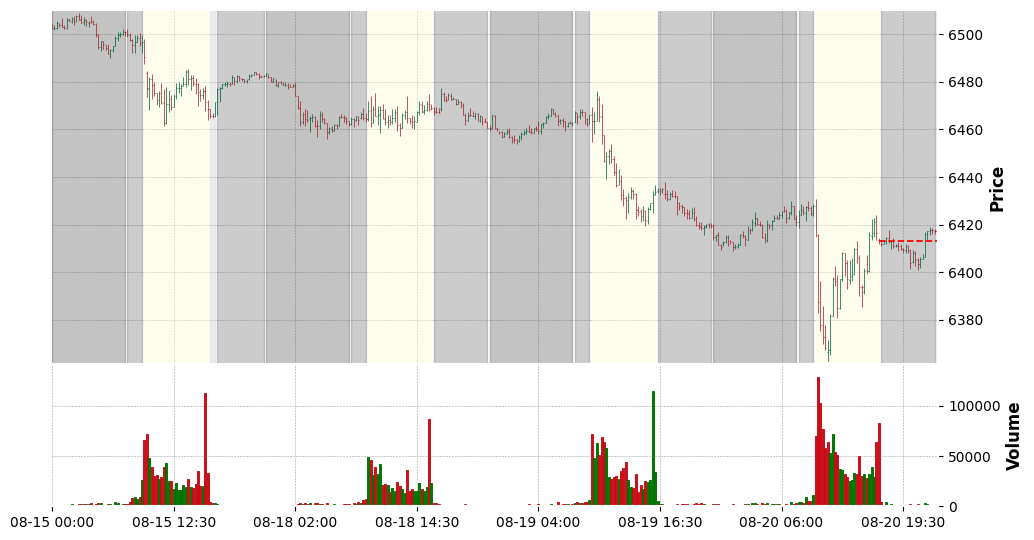

In [27]:
create_chart(df)

In [14]:
from utils.chart import add_symbol_to_svg

add_symbol_to_svg("data/es/chart.svg", "标普500期货")

## Slide
[top](#contents)

## Video Script
[top](#contents)

**Premium Computation**

Plug in real-time SPX, current rates, and exact days until expiry into:

$$
\text{Futures Price} = \text{Spot} × exp[(r − d) × T/365]
$$

to get live theoretical fair value.

Track dividend term structure tools (e.g., CME Dividend Futures) for expected dividend cash flows.

The \~50 point ES premium is primarily composed of:
- Dividends (\~16 points) – compensation for missing SPX dividends.
  - S&P 500 dividend yield is approximately 1.27% annually (as of Dec 2024) 
  - If SPX ≈ 5,000 and 3-month contract, then annual dividend ≈ 1.27% × 5,000 x 0.25 = 15.9 points.
- Financing/interest carry (\~34 points) – the cost to finance the futures position.
  - The cost-of-carry formula:
     $\text{Futures Price} ≈ \text{Spot} × e^(r − d) × t$
  - Assume short-term rates (r) \~ 5% (e.g., Fed funds or T-bill yield), while dividend yield (d) ≈ 1.27%.
  - Net carry rate ≈ r − d ≈ 3.73% annually.
  - If time to expiration (t) is \~3 months (0.25 year), the carry component ≈ 3.73% × 0.25 × 5,000 = ~46.6 points.

In [17]:
def get_premium_interpretation():
    """
    当前ES期货相较SPX现货约有50点溢价，主要反映了未来的利息成本与预期股息的差额。
    """
    return (
        "主要反映了未来的利息成本与预期股息的差额。"
    )

In [18]:
from decimal import Decimal


def es_video_script(c: EsTechnical) -> str:
    """
    标普500期货较现货呈现{premium}点的期货溢价。
    当前期货价格运行在日内高位区间，显示多头仍占据一定优势。
    目前ES期货维持在上升通道之中，若能有效站稳6100点上方，
    有望挑战前高压力区域。短线支撑关注6080点附近，
    若跌破，则需警惕回调风险。
    """
    if c.overnight_high is None or c.overnight_low is None:
        overnight_text = "No overnight data available."
    else:
        overnight_text = f"在接下来截至{c.overnight_last_time}的隔夜盘，标普500期货盘中最高上探至{c.overnight_high}点，最低回落至{c.overnight_low}点。"

    script = f"""
截至上一个交易日{c.rth_close_datetime}，标普500期货收于{c.rth_close_price}点。
标普500期货较现货呈现平均{c.premium_to_spot}点的期货溢价，{c.premium_interpretation}
{overnight_text}
    """
    return script.strip()

In [19]:
closing_datetime = get_last_close_datetime(df)
index, last = get_last_close_row(df)
last_close = last["Close"]
overnight_last = df.iloc[-1]
overnight_last_date = overnight_last.name.date().strftime("%Y-%m-%d")
overnight_last_time = overnight_last.name.time().strftime("%H:%M")
overnight_high, overnight_low = overnight_high_low(df)

print(f"ES-SPX Premium: {sprd_premium:.2f}")
print(f"ES-SPX Percent: {sprd_pct:.2f}%")
print(f"Last Date: {closing_datetime}")
print(f"Last Close: {last_close}")
print(f"Overnight Last: {overnight_last}")
print(f"Overnight Last Date: {overnight_last_date}")
print(f"Overnight Last Time: {overnight_last_time}")
print(f"Overnight High: {overnight_high}")
print(f"Overnight Low: {overnight_low}")

ES-SPX Premium: 33.52
ES-SPX Percent: 0.53%
Last Date: 2025-07-29 16:00:00
Last Close: 6403.75
Overnight Last: Close     6415.75
High      6416.50
Low       6415.00
Open      6415.00
Volume     482.00
Name: 2025-07-30 01:45:00-04:00, dtype: float64
Overnight Last Date: 2025-07-30
Overnight Last Time: 01:45
Overnight High: 6416.5
Overnight Low: 6402.0


In [20]:
data = {
    "name": "标普500期货",
    "interval": "15m",
    "rth_close_datetime": closing_datetime,
    "rth_close_price": "{:.2f}".format(last["Close"]),
    "premium_to_spot": "{:.2f}".format(sprd_premium),
    "premium_interpretation": get_premium_interpretation(),
    "overnight_last_date": overnight_last_date,
    "overnight_last_time": overnight_last_time,
    "overnight_high": "{:.2f}".format(overnight_high),
    "overnight_low": "{:.2f}".format(overnight_low),
}

In [21]:
data

{'name': '标普500期货',
 'interval': '15m',
 'rth_close_datetime': '2025-07-29 16:00:00',
 'rth_close_price': '6403.75',
 'premium_to_spot': '33.52',
 'premium_interpretation': '主要反映了未来的利息成本与预期股息的差额。',
 'overnight_last_date': '2025-07-30',
 'overnight_last_time': '01:45',
 'overnight_high': '6416.50',
 'overnight_low': '6402.00'}

In [ ]:
from utils.script import save_script, save_technical

c = EsTechnical(**data)
script = es_video_script(c)

filejson = "../output/data/es/technical.json"
save_technical(c, filejson)

filename = "../output/data/es/script.txt"
save_script(script, filename)

print(script)

截至上一个交易日2025-07-29 16:00:00，标普500期货收于6403.75点。
标普500期货较现货呈现平均33.52点的期货溢价，主要反映了未来的利息成本与预期股息的差额。
在接下来截至01:45的隔夜盘，标普500期货盘中最高上探至6416.50点，最低回落至6402.00点。


截至撰稿时，标普500期货交易价格仍高于上周五的交易区间，上升趋势依然完整。投资者需密切关注后续市场动向。